# Eşik Ayarlaması

👇 Çalışacağınız veri setini görmek için `player_performances.csv` oyuncu veri setini yükleyin.

In [1]:
import pandas as pd

!curl -s https://d32aokrjazspmn.cloudfront.net/materials/ML_Player_performance.csv > data/player_performances.csv

data = pd.read_csv('data/player_performances.csv')

data.head()

,games played,minutes played,points per game,field goals made,field goal attempts,field goal percent,3 point made,3 point attempt,3 point %,free throw made,free throw attempts,free throw %,offensive rebounds,defensive rebounds,rebounds,assists,steals,blocks,turnovers,target_5y
0,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,1.6,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,2.6,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,0.9,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0
3,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,22.6,0.9,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,0.0,1.3,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   games played         1328 non-null   int64  
 1   minutes played       1328 non-null   float64
 2   points per game      1328 non-null   float64
 3   field goals made     1328 non-null   float64
 4   field goal attempts  1328 non-null   float64
 5   field goal percent   1328 non-null   float64
 6   3 point made         1328 non-null   float64
 7   3 point attempt      1328 non-null   float64
 8   3 point %            1328 non-null   float64
 9   free throw made      1328 non-null   float64
 10  free throw attempts  1328 non-null   float64
 11  free throw %         1328 non-null   float64
 12  offensive rebounds   1328 non-null   float64
 13  defensive rebounds   1328 non-null   float64
 14  rebounds             1328 non-null   float64
 15  assists              1328 non-null   f

In [5]:
data.duplicated().sum()

11

In [7]:
data = data.drop_duplicates()

In [8]:
data.isnull().mean()

games played           0.0
minutes played         0.0
points per game        0.0
field goals made       0.0
field goal attempts    0.0
field goal percent     0.0
3 point made           0.0
3 point attempt        0.0
3 point %              0.0
free throw made        0.0
free throw attempts    0.0
free throw %           0.0
offensive rebounds     0.0
defensive rebounds     0.0
rebounds               0.0
assists                0.0
steals                 0.0
blocks                 0.0
turnovers              0.0
target_5y              0.0
dtype: float64

ℹ️ Her gözlem bir oyuncuyu temsil eder ve her sütun performansın bir özelliğidir. Hedef `target_5y`, oyuncunun 5 yıldan az [0] veya 5 yıl ve daha fazla [1] profesyonel kariyere sahip olup olmadığını tanımlar.

# Ön İşleme

👇 Ön işleme için çok fazla zaman harcamamak adına, tüm özellik setini Robust Scale ile ölçeklendirin. Bu uygulama optimal değildir, ancak ön işleme ve/veya modellerin hızla çalıştırılması için kullanılabilir.

Ölçeklendirilmiş özellik setini `X_scaled` olarak kaydedin.

In [11]:
X = data.drop(columns='target_5y')
y = data['target_5y']

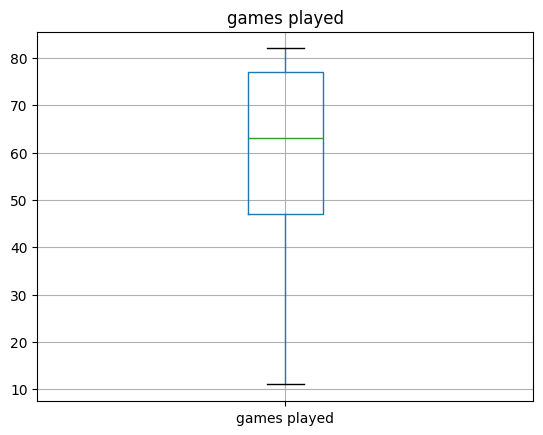

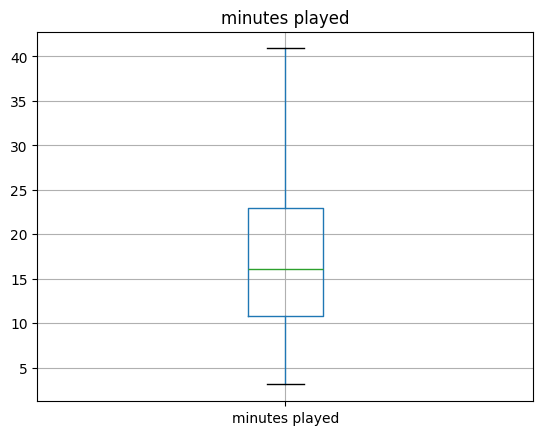

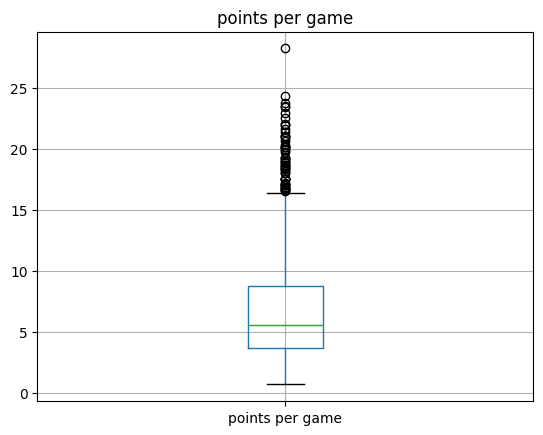

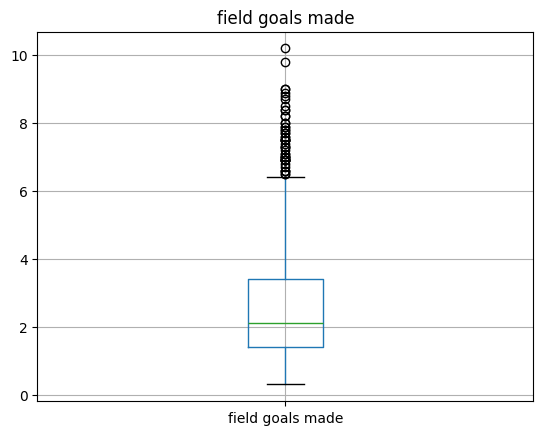

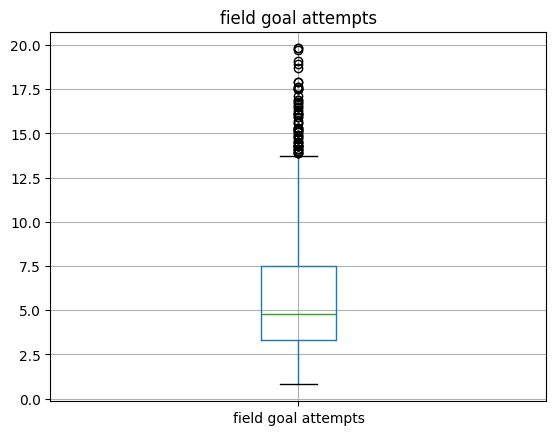

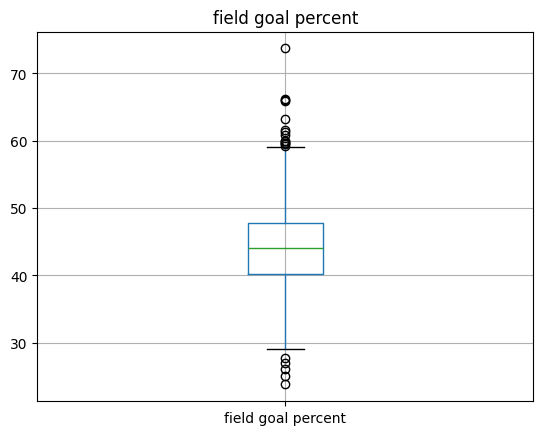

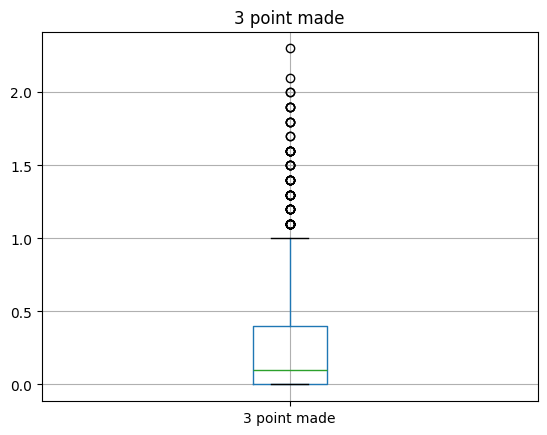

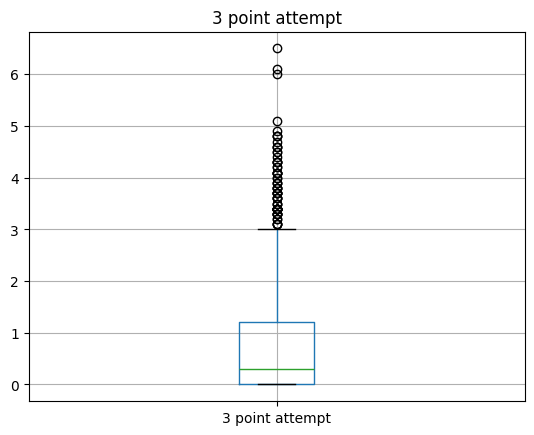

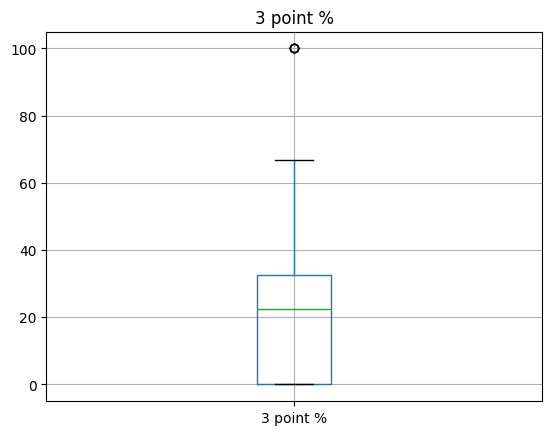

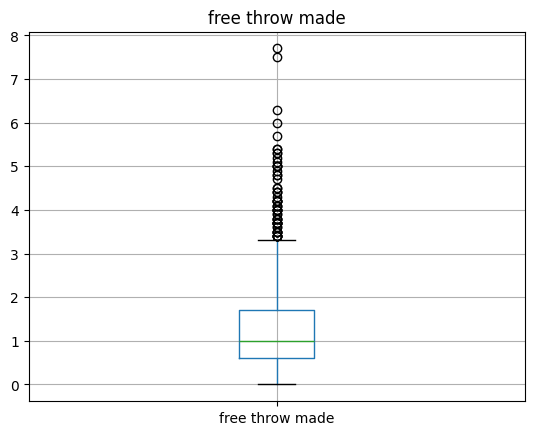

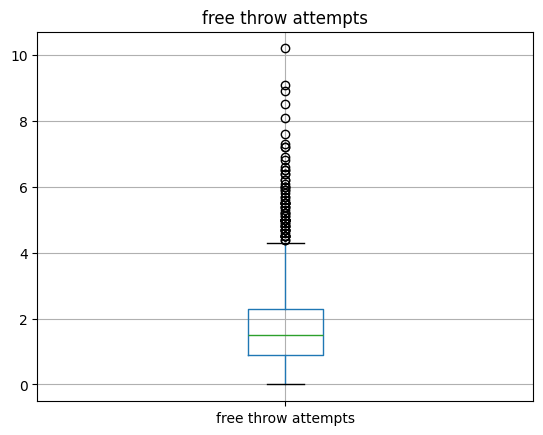

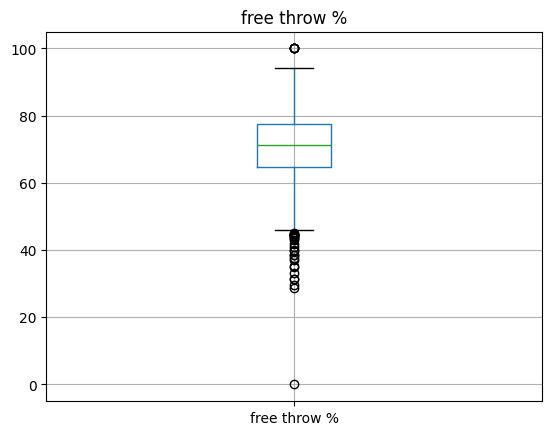

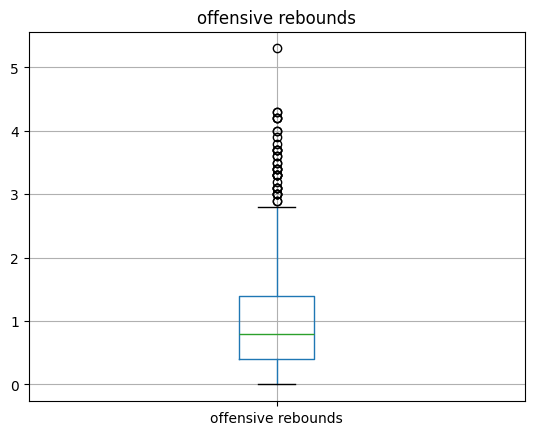

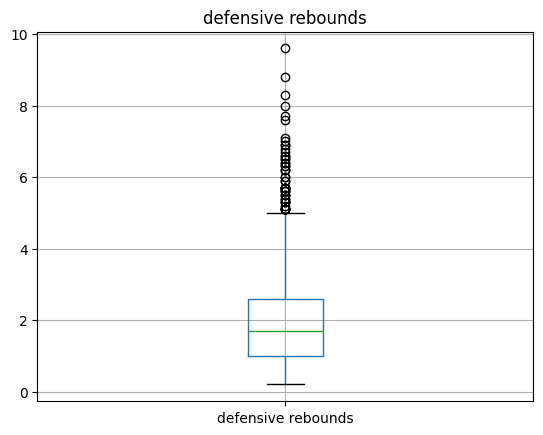

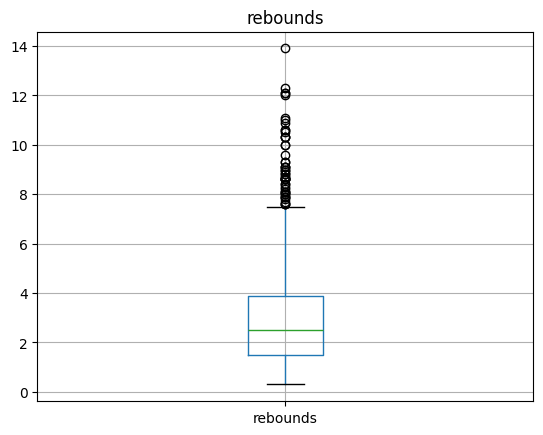

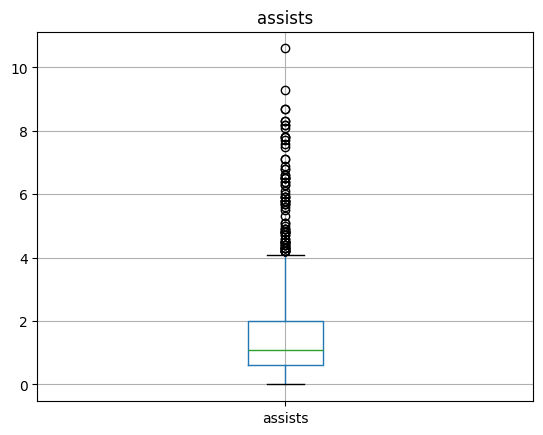

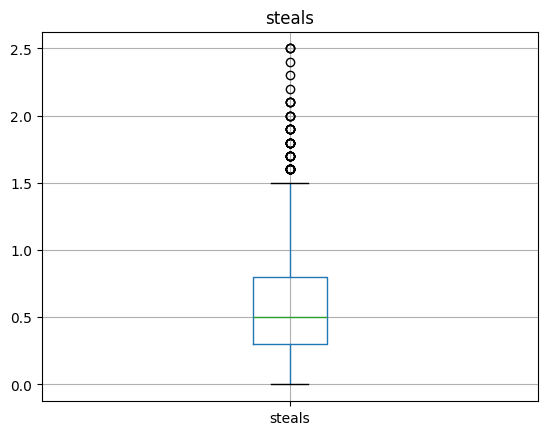

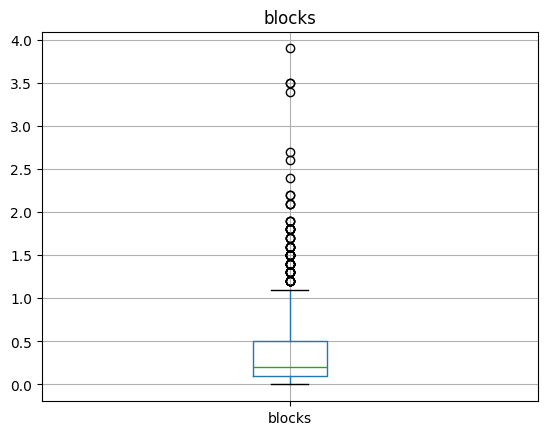

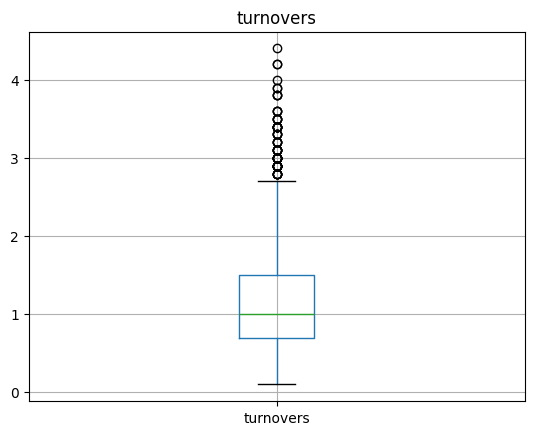

In [10]:
# YOUR CODE HERE
import matplotlib.pyplot as plt

for cols in X:
    plt.figure()
    X.boxplot(column=cols)
    plt.title(cols)
    plt.show()


<Axes: >

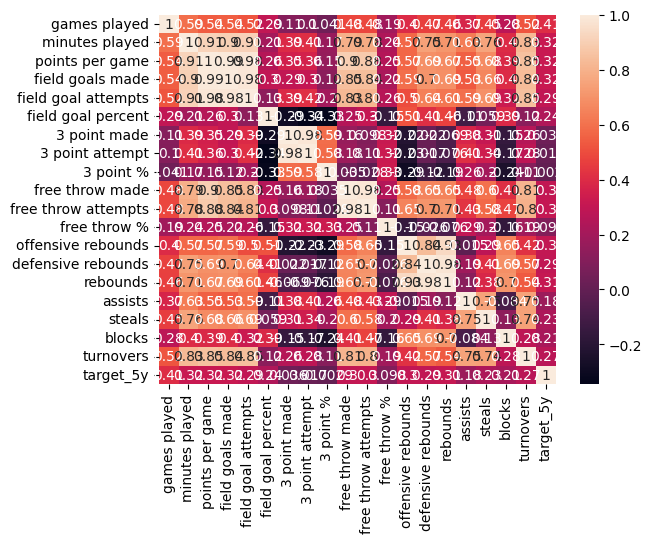

In [12]:
import seaborn as sbs

sbs.heatmap(data.corr(), annot=True)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler

pipe = Pipeline([
    ('scaler', RobustScaler())
])

In [16]:
pipe.fit(X)

Pipeline(steps=[('scaler', RobustScaler())])

In [18]:
X_scaled = pipe.named_steps['scaler'].transform(X)
X_scaled

array([[-0.9       ,  0.9338843 ,  0.35294118, ..., -0.2       ,
         0.5       ,  0.375     ],
       [-0.93333333,  0.89256198,  0.31372549, ...,  1.2       ,
         0.75      ,  0.75      ],
       [ 0.36666667, -0.0661157 , -0.07843137, ...,  0.        ,
         0.25      ,  0.        ],
       ...,
       [-0.66666667, -0.33057851, -0.03921569, ..., -0.4       ,
         0.5       , -0.125     ],
       [-0.36666667, -0.33884298, -0.21568627, ..., -0.2       ,
        -0.25      , -0.25      ],
       [-0.53333333, -0.36363636, -0.23529412, ...,  0.4       ,
        -0.25      , -0.125     ]])

### ☑️ Kodunuzu kontrol edin

In [19]:
from nbresult import ChallengeResult

result = ChallengeResult('scaled_features',
                         scaled_features = X_scaled
)

result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/elifcubukcu/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/elifcubukcu/S16D3-S-data-threshold/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_scaled_features.py::TestScaled_features::test_scaled_features PASSED [100%]

============================== 1 passed in 0.13s ===============================


💯 You can commit your code:

git add tests/scaled_features.pickle

git commit -m 'Completed scaled_features step'

git push origin master



# Temel Modelleme

🎯 Görev, %90 garantiyle minimum 5 yıl profesyonel olarak devam edecek oyuncuları tespit etmektir.

👇 Varsayılan bir Lojistik Regresyon modeli antrenörün gereksinimlerini karşılayacak mı? Çapraz doğrulama kullanın ve cevabınızı destekleyen skoru `base_score` değişken adı altında kaydedin.

In [24]:
# YOUR CODE HERE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

base_score = cross_val_score(pipe, X_scaled, y, cv=10, scoring='precision').mean()
base_score

0.7397020721609664

### ☑️ Kodunuzu kontrol edin

In [25]:
from nbresult import ChallengeResult

result = ChallengeResult('base_precision',
                         score = base_score
)

result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/elifcubukcu/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/elifcubukcu/S16D3-S-data-threshold/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_base_precision.py::TestBase_precision::test_precision_score PASSED  [100%]

============================== 1 passed in 0.12s ===============================


💯 You can commit your code:

git add tests/base_precision.pickle

git commit -m 'Completed base_precision step'

git push origin master



# Eşik Ayarlaması

👇 Bir oyuncunun profesyonel olarak 5 yıl veya daha fazla sürmesi için %90 kesinlik garantisi veren karar eşiğini bulun. Eşiği `new_threshold` değişken adı altında kaydedin.

<details>
<summary>💡 İpucu</summary>

- [`cross_val_predict`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html) ile çapraz doğrulanmış olasılık tahminleri yapın
    
- Farklı eşiklerde kesinlik skorları oluşturmak için olasılıkları [`precision_recall_curve`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html) içine yerleştirin

- 0.9 kesinliği garanti eden eşiği bulun
      
</details>

In [29]:
# YOUR CODE HERE
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

class ThresholdClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator, threshold=0.5):
        self.estimator = estimator
        self.threshold = threshold

    def fit(self, X_scaled, y):
        self.estimator_ = clone(self.estimator)
        self.estimator_.fit(X_scaled, y)
        self.classes_ = self.estimator_.classes_
        return self

    def predict_proba(self, X_scaled):
        return self.estimator_.predict_proba(X)

    def predict(self, X):
        proba = self.predict_proba(X_scaled)[:, 1]
        return (proba >= self.threshold).astype(int)


y_proba = cross_val_predict(
    pipe,
    X_scaled,
    y,
    cv=5,
    method="predict_proba"
)[:, 1]

precision, recall, thresholds = precision_recall_curve(y, y_proba)

valid_idx = np.where(precision[:-1] >= 0.90)[0]

if len(valid_idx) > 0:
    new_threshold = thresholds[valid_idx[0]]
else:
    new_threshold = 0.5

final_model = ThresholdClassifier(
    estimator=pipe,
    threshold=new_threshold
)

final_model.fit(X_scaled, y)

print("New threshold:", new_threshold)


New threshold: 0.8527650135771151


In [35]:
decision_threshold = new_threshold

### ☑️ Kodunuzu kontrol edin

In [36]:
from nbresult import ChallengeResult

result = ChallengeResult('decision_threshold',
                         threshold = new_threshold
)

result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/elifcubukcu/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/elifcubukcu/S16D3-S-data-threshold/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_decision_threshold.py::TestDecision_threshold::test_new_threshold PASSED [100%]

============================== 1 passed in 0.14s ===============================


💯 You can commit your code:

git add tests/decision_threshold.pickle

git commit -m 'Completed decision_threshold step'

git push origin master



# Yeni Eşiği Kullanma

🎯 Antrenör potansiyel olarak ilginç bir oyuncu fark etti, ancak bu oyuncunun minimum 5 yıl profesyonel olarak devam edeceğine dair %90 garantinizi istiyor. Oyuncunun verilerini [buradan](https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/ML_New_player.csv) indirin.

In [37]:
new_player = pd.read_csv("https://d32aokrjazspmn.cloudfront.net/materials/ML_New_player.csv")

new_player

,games played,minutes played,points per game,field goals made,field goal attempts,field goal percent,3 point made,3 point attempt,3 point %,free throw made,free throw attempts,free throw %,offensive rebounds,defensive rebounds,rebounds,assists,steals,blocks,turnovers
0,80,31.4,14.3,5.9,11.1,52.5,0.0,0.1,11.1,2.6,3.9,65.4,3.0,5.0,8.0,2.4,1.1,0.8,2.2


❓ Oyuncuyu antrenöre tavsiye etmeyi göze alır mısınız? Cevabınızı string olarak `recommendation` değişken adı altında "recommend" veya "not recommend" şeklinde kaydedin.

In [44]:
# YOUR CODE HERE
proba = final_model.predict_proba(new_player)[0,1]

recommendation = 'Recommend' if proba > new_threshold else 'Not recommend'
recommendation

/Users/elifcubukcu/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RobustScaler was fitted without feature names
  warnings.warn(


'Recommend'

### ☑️ Kodunuzu kontrol edin

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult('recommendation',
                         recommendation = recommendation
)

result.write()
print(result.check())

# 🏁